<a href="https://colab.research.google.com/github/brightliam20-ops/AVCAD-ASSIGNMENT/blob/main/Assignment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Agglomerative Clustering and Visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

### 1. Data Loading and Filtering

First, we need to load the environmental data. Please replace `'path/to/your/environmental_data.csv'` with the actual path to your dataset. This example assumes your data has columns for 'Site', 'Basin', and various quantitative environmental variables. The 'Basin' column is used for filtering.

In [2]:
# Load the environmental data (replace with your actual data path)
# Example DataFrame structure assumed: 'Site', 'Basin', and other numeric environmental variables
# For demonstration, I'll create a dummy DataFrame.
data = {
    'Site': ['Site_1_Douro', 'Site_2_Douro', 'Site_3_Tejo', 'Site_4_Douro', 'Site_5_Tejo', 'Site_6_Douro', 'Site_7_Tejo'],
    'Basin': ['Douro', 'Douro', 'Tejo', 'Douro', 'Tejo', 'Douro', 'Tejo'],
    'Var_A': [10, 12, 5, 11, 6, 13, 7],
    'Var_B': [2, 3, 8, 2.5, 7.5, 3.5, 9],
    'Var_C': [100, 105, 90, 103, 92, 108, 95],
    'Var_D': [0.5, 0.6, 0.2, 0.55, 0.25, 0.62, 0.28]
}
df = pd.DataFrame(data)

# In a real scenario, you would do:
# df = pd.read_csv('path/to/your/environmental_data.csv')

print("Original DataFrame head:")
display(df.head())


Original DataFrame head:


,Site,Basin,Var_A,Var_B,Var_C,Var_D
0,Site_1_Douro,Douro,10,2.0,100,0.50
1,Site_2_Douro,Douro,12,3.0,105,0.60
2,Site_3_Tejo,Tejo,5,8.0,90,0.20
3,Site_4_Douro,Douro,11,2.5,103,0.55
4,Site_5_Tejo,Tejo,6,7.5,92,0.25


In [3]:
# Filter for sites from Douro and Tejo basins
df_filtered = df[df['Basin'].isin(['Douro', 'Tejo'])].copy()

# Set 'Site' as the index for clustering
df_clust = df_filtered.set_index('Site').drop(columns=['Basin'])

print("DataFrame filtered for Douro and Tejo basins, ready for clustering (head):")
display(df_clust.head())
print(f"Shape of data for clustering: {df_clust.shape}")

DataFrame filtered for Douro and Tejo basins, ready for clustering (head):


,Var_A,Var_B,Var_C,Var_D
Site,,,,
Site_1_Douro,10,2.0,100,0.50
Site_2_Douro,12,3.0,105,0.60
Site_3_Tejo,5,8.0,90,0.20
Site_4_Douro,11,2.5,103,0.55
Site_5_Tejo,6,7.5,92,0.25


Shape of data for clustering: (7, 4)


### 2. Agglomerative Clustering with Different Linkage Methods (Sites)

We will perform hierarchical clustering on the sites using different linkage methods: 'ward', 'complete', 'average', and 'single'. The `linkage` function from `scipy.cluster.hierarchy` computes the linkage matrix, which is then used to visualize the dendrogram.

In [4]:
# Perform agglomerative clustering using different linkage methods
linkage_methods = ['ward', 'complete', 'average', 'single']
linkage_matrices = {}

print("Performing clustering with different linkage methods:")
for method in linkage_methods:
    print(f"  - Method: {method}")
    linkage_matrices[method] = linkage(df_clust, method=method)

print("\nLinkage matrices calculated for all methods.")

Performing clustering with different linkage methods:
  - Method: ward
  - Method: complete
  - Method: average
  - Method: single

Linkage matrices calculated for all methods.


### 3. Plotting Heatmap and Dendrogram for Sites (Average Linkage)

Now, let's visualize the clustering results for the sites using the 'average' linkage method. A heatmap combined with a dendrogram is an excellent way to see both the clusters and the actual values of the variables.

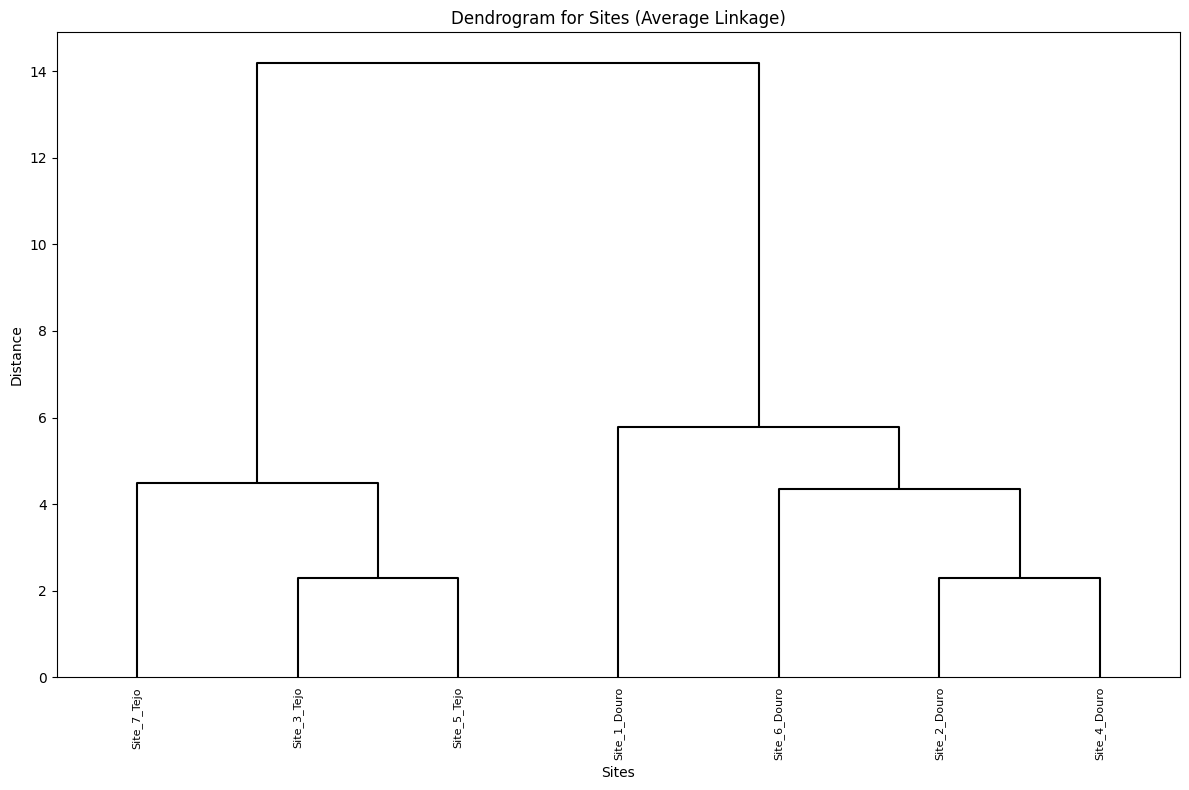

In [5]:
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrices['average'],
           labels=df_clust.index.to_list(),
           leaf_rotation=90,
           leaf_font_size=8,
           color_threshold=0, # This ensures all lines are colored until specified
           above_threshold_color='black') # Color branches above threshold black
plt.title('Dendrogram for Sites (Average Linkage)')
plt.xlabel('Sites')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

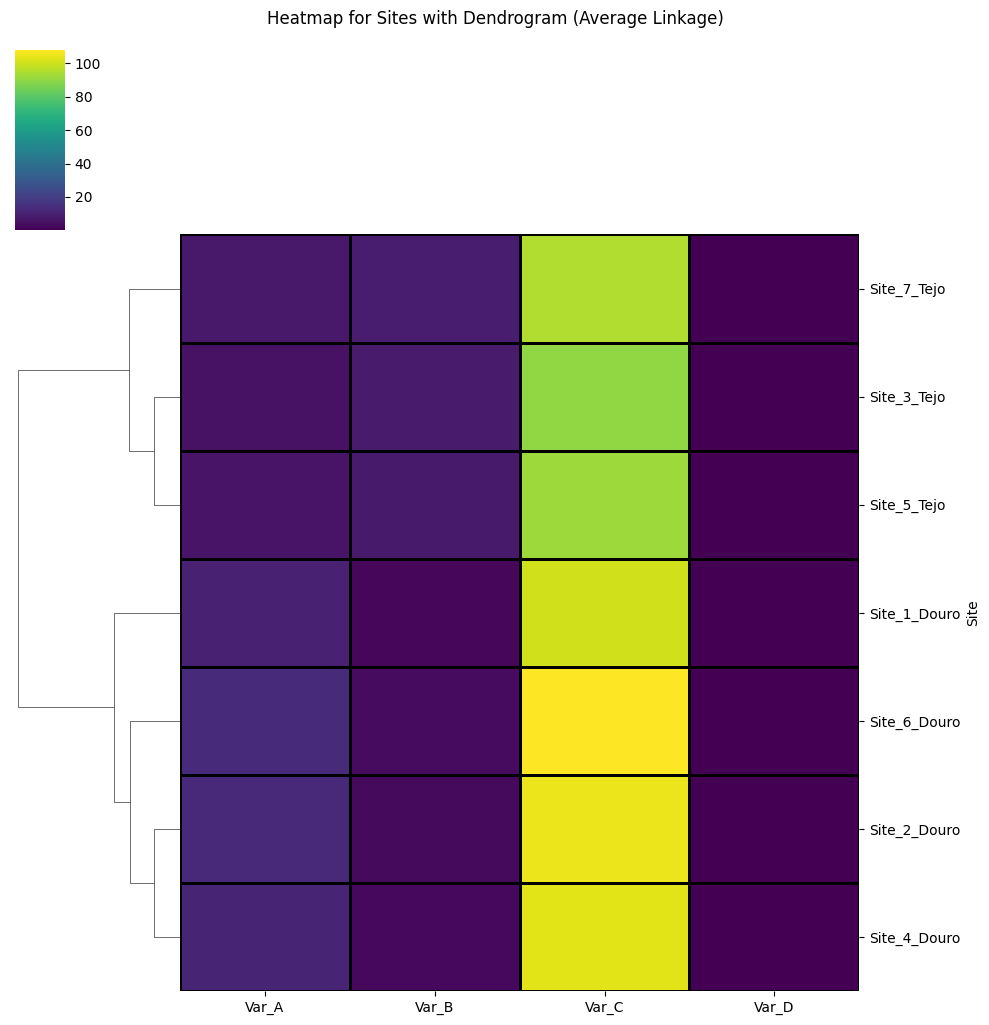

In [6]:
# Plot heatmap with dendrogram
sns.clustermap(df_clust,
               method='average',
               cmap='viridis',
               figsize=(10, 10),
               row_cluster=True,  # Cluster rows (sites)
               col_cluster=False, # Do not cluster columns yet, we'll do that separately
               linewidths=.75,
               linecolor='black')
plt.suptitle('Heatmap for Sites with Dendrogram (Average Linkage)', y=1.02) # Adjust suptitle position
plt.show()

### 4. Plotting Dendrogram for Environmental Variables (Columns) (Average Linkage)

To cluster the environmental variables (columns) instead of the sites (rows), we need to transpose the DataFrame. This allows us to see which variables group together based on their values across the sites.

Clustering variables can be very helpful for selecting variables for regression-based analysis. If variables are highly correlated and form a tight cluster, they might be measuring similar aspects. In such cases, you might choose to:

*   **Select one representative variable** from the cluster to avoid multicollinearity.
*   **Combine them** into a single composite variable or index.
*   **Understand underlying latent factors** that these variables represent.

This helps in simplifying the model, improving interpretability, and potentially reducing overfitting by removing redundant information.

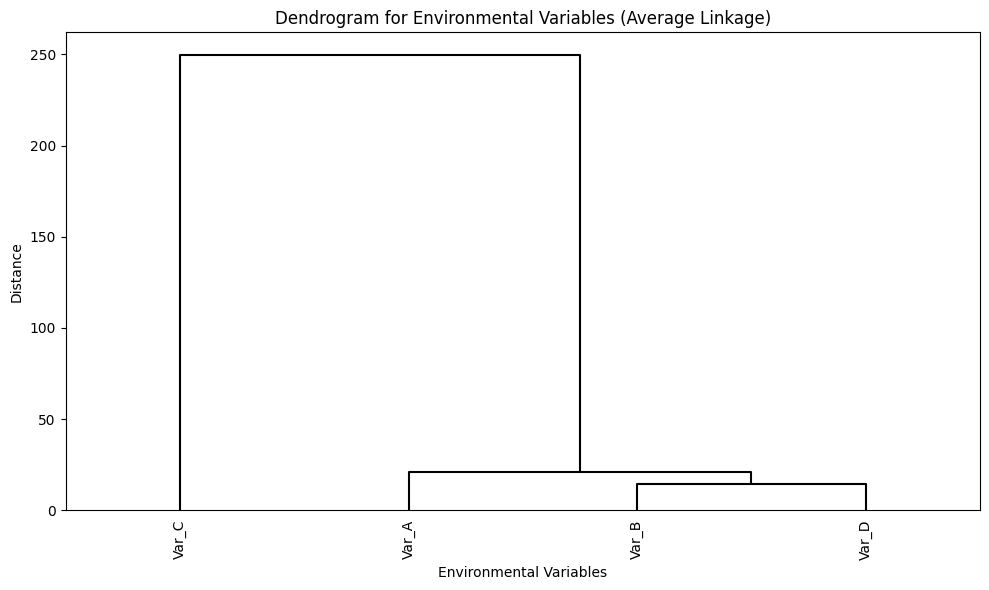

In [7]:
# Transpose the DataFrame to cluster columns (environmental variables)
df_vars_transposed = df_clust.T

# Perform agglomerative clustering on the transposed DataFrame using average linkage
linkage_vars = linkage(df_vars_transposed, method='average')

plt.figure(figsize=(10, 6))
dendrogram(linkage_vars,
           labels=df_vars_transposed.index.to_list(),
           leaf_rotation=90,
           leaf_font_size=10,
           color_threshold=0,
           above_threshold_color='black')
plt.title('Dendrogram for Environmental Variables (Average Linkage)')
plt.xlabel('Environmental Variables')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()